In [68]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
import joblib

data_path = 'ground_truth.csv'
df = pd.read_csv(data_path)

# Unique patients
print('Number of unique patients: ', list(df['patient_id'].unique()), sep='\n')

# Building patient features
patient_features = []
for pid, g in df.groupby('patient_id'):
    feat = {}

    # static features
    feat['patient_id'] = pid
    feat['vv'] = g['vv'].iloc[0]
    feat['fmax'] = g['fmax'].iloc[0]
    feat['Aum_Aminze'] = g['Aum/Aminze'].iloc[0]

    #  compute signal statistcis
    for col in ['f_um', 'f_oppo', 'f_phone']:
        feat[f'{col}_mean'] = g[col].mean()
        feat[f'{col}_std'] = g[col].std()
        feat[f'{col}_max'] = g[col].max()
        feat[f'{col}_min'] = g[col].min()
        feat[f'{col}_skew'] = skew(g[col])
        feat[f'{col}_kurtosis'] = kurtosis(g[col])

        # area under curve
        feat[f'{col}_auc'] = np.trapezoid(g[col])

        # slope
        feat[f'{col}_slope'] = np.polyfit(
            np.arange(len(g[col])),
            g[col],
            1
        )[0]
    patient_features.append(feat)
patient_df = pd.DataFrame(patient_features)
print('Extracted statistical properties', patient_df.head(5), sep='\n')

# normalize features
X = patient_df.drop(columns=['patient_id'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Number of unique patients: 
['v14', 'v56', 'v19', 'v49', 'v22', 'v60', 'v61', 'v73', 'v69', 'v16', 'v37', 'v53', 'v68', 'v18', 'v74', 'v25', 'v54', 'v64', 'v11', 'v80', 'v63', 'v42', 'v59', 'v29', 'v32', 'v30', 'v35', 'v43', 'v33', 'v47', 'v40', 'v55', 'v39', 'v27', 'v57', 'v36', 'v46', 'v67', 'v62', 'v23', 'v58', 'v77', 'v72', 'v31', 'v78', 'v21']
Extracted statistical properties
  patient_id     vv  fmax  Aum_Aminze   f_um_mean    f_um_std   f_um_max  \
0        v11  145.9  23.0       40.42  393.052245  385.800523  1012.9768   
1        v14  236.6  30.0       44.48  478.416276  347.362740  1014.3493   
2        v16  442.7  26.0       37.36  472.567724  315.653476   908.8738   
3        v18  167.8  18.0       45.63  364.678896  292.347794   855.5379   
4        v19  496.7  27.0       40.50  529.396905  367.537666  1036.5005   

   f_um_min  f_um_skew  f_um_kurtosis  ...    f_oppo_auc  f_oppo_slope  \
0       0.0   0.400597      -1.596713  ...  22588.713566     -0.259117   
1       0.0

Patient clusters
   clusters_kmeans  clusters_gmm
0                0             0
1                0             0
2                0             0
3                0             0
4                0             0
5                0             0
6                0             0
7                0             0
8                0             0
9                0             0


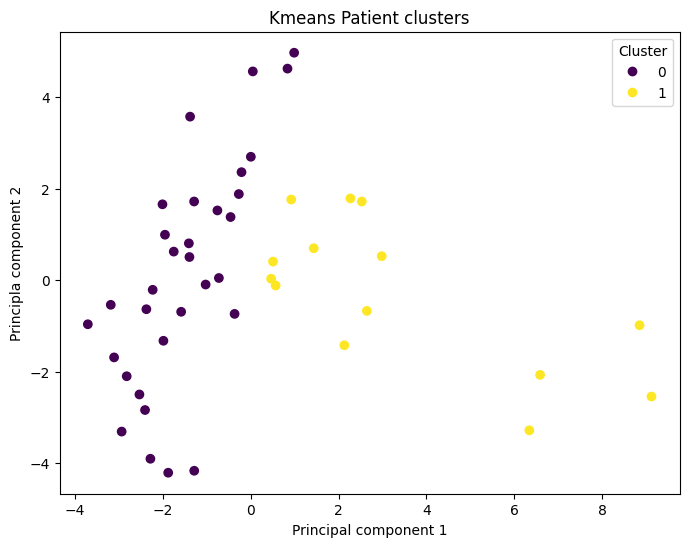

<Figure size 640x480 with 0 Axes>

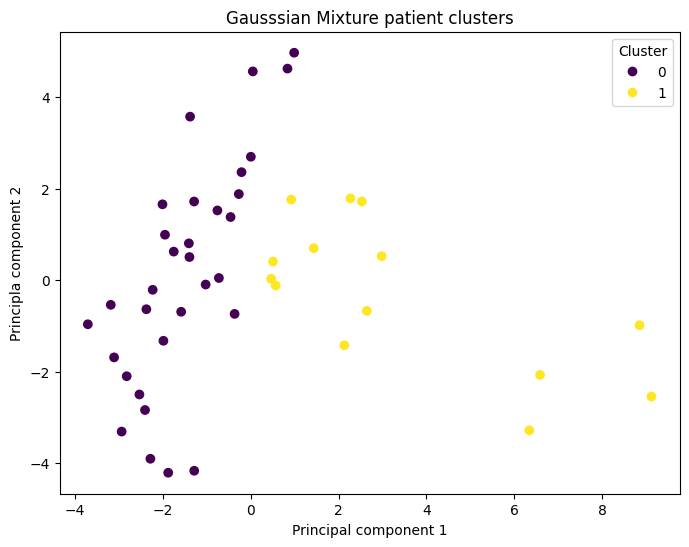

In [69]:
kmeans = KMeans(n_clusters=2, random_state=42) # create k_means obj of 2 clusters
gmm = GaussianMixture(n_components=2, random_state=42) 
clusters_means = kmeans.fit_predict(X_scaled)
clusters_gmm = gmm.fit_predict(X_scaled)

patient_df['clusters_kmeans'] = clusters_means
patient_df['clusters_gmm'] = clusters_gmm
print(f'Patient clusters', patient_df.loc[:, ['clusters_kmeans', 'clusters_gmm']].head(10),sep='\n')


# pca computations
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=patient_df['clusters_kmeans'])
plt.xlabel('Principal component 1')
plt.ylabel('Principla component 2')
plt.title('Kmeans Patient clusters')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()
plt.savefig('kmeans_patient_clusters.png')

# visualize the GMM clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=patient_df['clusters_gmm'])
plt.xlabel('Principal component 1')
plt.ylabel('Principla component 2')
plt.title('Gausssian Mixture patient clusters')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.savefig('gaussain_mixtures_patient_clusters.png')
plt.show()


In [70]:
# sampling patients for uroflow medic prep
cluster_0_mask = patient_df['clusters_kmeans'] == 0
cluster_0_patients = patient_df[cluster_0_mask]['patient_id']
cluster_1_patients = patient_df[~cluster_0_mask]['patient_id']

joblib.dump(kmeans, 'kmeans_uroflow_clustering_model.pkl')
joblib.dump(gmm, 'gmm_uroflow_clustering_model.pkl')
cluster_1_patients.to_csv('class_one_patients.csv')
cluster_0_patients.to_csv('class_1_patients.csv')